In [1]:
# YOLOv8 설치 및 모델 준비
!pip install -q ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


--2026-06-14 23:46:50--  https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 279603 (273K) [image/jpeg]
Saving to: ‘people_animals.jpg’

people_animals.jpg  100%[===================>] 273.05K  --.-KB/s    in 0.009s  

2026-06-14 23:46:50 (30.5 MB/s) - ‘people_animals.jpg’ saved [279603/279603]


image 1/1 /content/people_animals.jpg: 640x640 1 cat, 509.8ms
Speed: 11.9ms preprocess, 509.8ms inference, 53.3ms postprocess per image at shape (1, 3, 640, 640)
Detected people: 0
Detected animals: 1


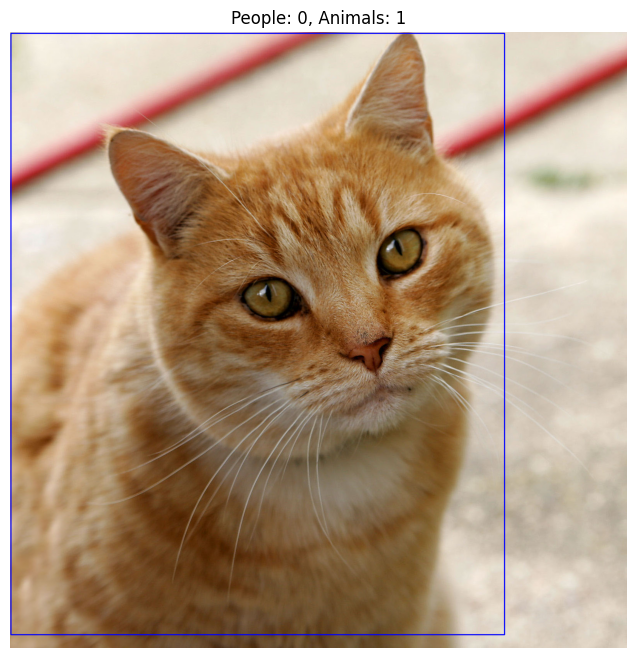

In [2]:
# Wikimedia: 개와 사람 (dog+person)
!wget -O people_animals.jpg https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg



# 1) 모델 불러오기
model = YOLO('yolov8n.pt')

# 2) 탐지 수행
results = model('people_animals.jpg')

# 3) 사람/동물 클래스 정의
person_class = 'person'
animal_classes = [
    'cat', 'dog', 'bird', 'sheep', 'cow', 'horse',
    'elephant', 'bear', 'zebra', 'giraffe'
]

# 4) 탐지 결과 분류
img = cv2.imread('people_animals.jpg')
person_count = 0
animal_count = 0

for r in results:
    for box, label, conf in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy(), r.boxes.conf.cpu().numpy()):
        name = model.names[int(label)]
        x1, y1, x2, y2 = map(int, box)
        if name == person_class:
            color = (0, 255, 0)    # Green for person
            person_count += 1
            tag = 'Person'
        elif name in animal_classes:
            color = (255, 0, 0)    # Blue for animal
            animal_count += 1
            tag = name.capitalize()
        else:
            continue
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f'{tag} {conf:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

print(f"Detected people: {person_count}")
print(f"Detected animals: {animal_count}")

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"People: {person_count}, Animals: {animal_count}")
plt.show()